 # 4 - Evaluation and Enchancement 

 ##### This notebook evaluates the retrival systen quantitatively 
 ##### and introduces descriptors improvements (PCA or Spatial Grid)

 ##### This notebook consists of : 
##### - Compute Precision-Recall curves and mAP
##### - Measure retrieval runtime 
##### - Apply PCA to compress descriptors
##### - compare baseline vs enchanced system


### Import and Setup 

In [4]:
import sys
import time 
import pickle
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from pathlib import Path
from tqdm import tqdm 
from sklearn.decomposition import PCA 
from sklearn.metrics import precision_recall_curve , auc

sns.set(style="whitegrid")

# Setting the Path of our code
sys.path.append(str(Path("../").resolve()))
from src.extractors.color_hist import color_histogram,ColorHistConfig
from src.utils.io_utils import list_images

#### Loading the Descriptor Database

In [5]:
DATA_DIR = Path("../data/MSRC_ObjCategImageDatabase_v2/Images")
DESC_PATH = Path("../data/Descriptors/HSV_8x8x8.pkl")

db = pickle.load(open(DESC_PATH,"rb"))
desc_db = {k:v for k,v in db["descriptors"].items() if "_GT" not in k}
cfg = db["config"]
print(f"Descriptor Loaded {len(desc_db)}")

Descriptor Loaded 607


#### Distance Metrics 
#### - Manhattan Difference : Measures Absolute Difference 
#### - Euclidean Distance : Geometric Straight line Distance 
#### - Chi-Square  : Compares ratios of frequencies: Best for histograms 

In [6]:
def manhattan_dist(a,b):
    return np.sum(np.abs(a-b))

def Euclidean_dist(a,b):
    return np.sqrt(np.sum((a-b)**2))

def chi_sqr(a,b,eps=1e-10):
    return 0.5*np.sum(((a-b)**2)/(a+b+eps))

metric_functions ={"l1":manhattan_dist,
                   "l2":Euclidean_dist,   ### Using shorter names to call them throughout my notebook 
                   "chi":chi_sqr}

In [7]:
def rank(query_vec, desc_db, dist_fn):
    dists = [(k, dist_fn(query_vec,v)) for k,v in desc_db.items()]
    return sorted(dists, key=lambda x:x[1])

def compute_pr_curve(query_vec, desc_db, dist_fn, relevant_set):
    distances, labels = [], []
    for k,v in desc_db.items():
        d = dist_fn(query_vec, v)
        distances.append(d)
        labels.append(1 if k in relevant_set else 0)
    y_score = -np.array(distances)  # smaller = better
    precision, recall, _ = precision_recall_curve(labels, y_score)
    return precision, recall, auc(recall, precision)


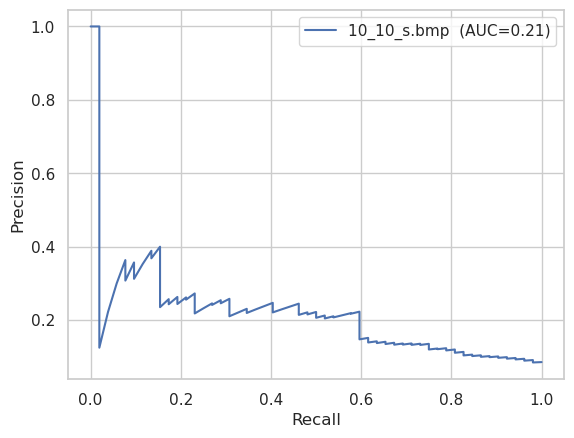

In [10]:
query_name = list(desc_db.keys())[0]
query_vec  = desc_db[query_name]
# pick a few "relevant" images manually (same colour/theme)
relevant_set = [k for k in desc_db.keys() if query_name.split("_")[0] in k]

p,r,a = compute_pr_curve(query_vec, desc_db, chi_sqr, relevant_set)
plt.plot(r,p,label=f"{query_name}  (AUC={a:.2f})")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.legend(); plt.show()


In [12]:
import statistics
times=[]
for q in np.random.choice(list(desc_db.keys()), 10, replace=False):
    start=time.time()
    _=rank(desc_db[q], desc_db, chi_sqr)
    times.append(time.time()-start)
print(f"Average retrieval time/query: {statistics.mean(times):.4f} s")


Average retrieval time/query: 0.0060 s


In [13]:
# Stack descriptors into matrix
X = np.array(list(desc_db.values()))
print("Original shape:", X.shape)

# Fit PCA to retain 95 % variance
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X)
print("Reduced shape:", X_pca.shape)

# Replace descriptors with reduced ones
reduced_db = {k: X_pca[i] for i,k in enumerate(desc_db.keys())}

# Save new descriptor file
OUT = Path("../data/Descriptors/HSV_PCA.pkl")
pickle.dump({"config": cfg, "descriptors": reduced_db, "pca": pca}, open(OUT,"wb"))
print("✅ PCA descriptors saved:", OUT)


Original shape: (607, 512)
Reduced shape: (607, 96)
✅ PCA descriptors saved: ../data/Descriptors/HSV_PCA.pkl


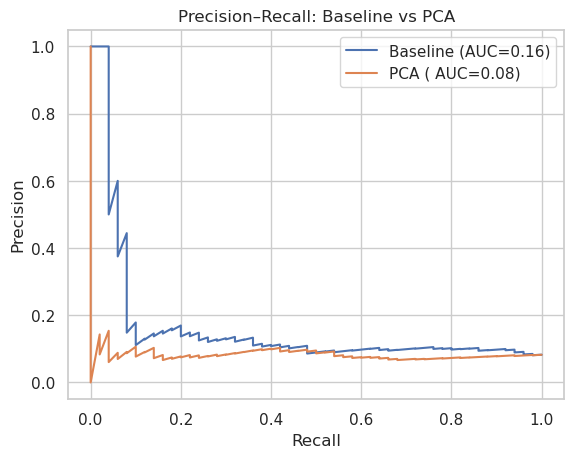

In [17]:
query_name = np.random.choice(list(desc_db.keys()))
query_vec  = desc_db[query_name]
relevant_set = [k for k in desc_db.keys() if query_name.split("_")[0] in k]

# Baseline
p1,r1,a1 = compute_pr_curve(query_vec, desc_db, chi_sqr, relevant_set)
# PCA version
query_vec_pca = reduced_db[query_name]
p2,r2,a2 = compute_pr_curve(query_vec_pca, reduced_db, chi_sqr, relevant_set)

plt.plot(r1,p1,label=f"Baseline (AUC={a1:.2f})")
plt.plot(r2,p2,label=f"PCA ( AUC={a2:.2f})")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.legend(); plt.title("Precision–Recall: Baseline vs PCA")
plt.show()
